# Book Reviews: Exploratory Analsyis

First step is to load the libraries needed for the EDA.

In [52]:
import pandas as pd
import statsmodels.api as sm
import re
import seaborn as sns; sns.set_theme(context='notebook')
import matplotlib.pyplot as plt 
from tldextract import extract

## Load data

I'm using data I've scraped from [Book Marks](https://bookmarks.reviews), which is a review aggregator site for books. My github repository [here](https://github.com/thepufferfish/bookmarks) holds the Python code used to scrape the site using the [scrapy](https://docs.scrapy.org/en/latest/) framework. Output is stored in a JSON Lines file. Each line gives a book title, author, publisher, publish date, description, list of genres, a link to the review, and a reviews stored in a list in JSON format. I add a unique integer identifier for each book to make later merges better; this is just the index of the DataFrame. Here's a preview of the data:

In [53]:
df = pd.read_json('../data/books.jsonl', lines=True)
df.loc[:,'book_id'] = df.index
df.head(10)

,title,author,publisher,publish_date,description,genres,link,last_scraped,reviews,book_id
0,Kingdom of No Tomorrow,Fabienne Josaphat,Algonquin Books,"December 3, 2024",The story of a young Haitian woman in Californ...,[Fiction],https://bookmarks.reviews/reviews/kingdom-of-n...,2025-02-01 16:46:35,"[{'review_author': 'Laura Warrell,', 'review_p...",0
1,This Isn't Going to End Well: The True Story o...,Daniel Wallace,Algonquin Books,"April 11, 2023",Author of Big Fish Daniel Wallace tries to com...,"[Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/this-isnt-go...,2025-02-01 16:46:58,"[{'review_author': 'Joan Frank,', 'review_publ...",1
2,"True West: Sam Shepard's Life, Work, and Times",Robert Greenfield,Crown,"April 11, 2023",A biography of the world-famous playwright and...,"[Biography, Film & TV, Non-Fiction]",https://bookmarks.reviews/reviews/true-west-sa...,2025-02-01 16:48:09,"[{'review_author': 'Ethan Hawke,', 'review_pub...",2
3,Small Mercies,Dennis Lehane,Harper,"April 25, 2023",In the summer of 1974 a heatwave blankets Bost...,"[Fiction, Hottest Books of the Season, Literar...",https://bookmarks.reviews/reviews/small-mercies/,2025-02-01 16:48:36,"[{'review_author': 'Laura Miller,', 'review_pu...",3
4,"Bruno Schulz: An Artist, a Murder, and the Hij...",Benjamin Balint,W. W. Norton & Company,"April 11, 2023",A fresh portrait of the Polish-Jewish writer a...,"[Biography, Non-Fiction]",https://bookmarks.reviews/reviews/bruno-schulz...,2025-02-01 16:49:52,"[{'review_author': 'Joshua Cohen,', 'review_pu...",4
5,I Could Live Here Forever,Hanna Halperin,Viking,"April 11, 2023",When Leah Kempler meets Charlie Nelson in line...,"[Fiction, Literary]",https://bookmarks.reviews/reviews/i-could-live...,2025-02-01 16:50:21,"[{'review_author': 'Leigh Haber,', 'review_pub...",5
6,The Covenant of Water,Abraham Verghese,Grove Press,"May 2, 2023",From the author of Cutting for Stone comes an ...,"[Fiction, Hottest Books of the Season, Literary]",https://bookmarks.reviews/reviews/the-covenant...,2025-02-01 16:51:26,"[{'review_author': 'Joan Frank,', 'review_publ...",6
7,"Look at the Lights, My Love","Annie Ernaux, trans. Alison L. Strayer",Yale University Press,"April 4, 2023",Annie Ernaux turns her attention to the phenom...,"[Literature in Translation, Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/look-at-the-...,2025-02-01 16:51:48,"[{'review_author': 'Kate Briggs,', 'review_pub...",7
8,Camp Zero,Michelle Min Sterling,Atria Books,"April 4, 2023","In a near-future northern settlement, the fate...","[Fiction, Speculative]",https://bookmarks.reviews/reviews/camp-zero/,2025-02-01 16:52:54,"[{'review_author': 'Houman Barekat,', 'review_...",8
9,Getting Out of Saigon: How a 27-Year-Old Banke...,Ralph White,Simon & Schuster,"April 4, 2023",The true story of author Ralph White's effort ...,"[Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/getting-out-...,2025-02-01 16:53:11,"[{'review_author': 'Mark Atwood Lawrence,', 'r...",9


## EDA

In [54]:
df_books = df[['book_id', 'title', 'author', 'publisher', 'publish_date', 'description', 'genres', 'link']]
print(df_books[['title', 'author', 'publisher']].nunique())
df_books.head(10)

title        12062
author        9974
publisher      846
dtype: int64


,book_id,title,author,publisher,publish_date,description,genres,link
0,0,Kingdom of No Tomorrow,Fabienne Josaphat,Algonquin Books,"December 3, 2024",The story of a young Haitian woman in Californ...,[Fiction],https://bookmarks.reviews/reviews/kingdom-of-n...
1,1,This Isn't Going to End Well: The True Story o...,Daniel Wallace,Algonquin Books,"April 11, 2023",Author of Big Fish Daniel Wallace tries to com...,"[Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/this-isnt-go...
2,2,"True West: Sam Shepard's Life, Work, and Times",Robert Greenfield,Crown,"April 11, 2023",A biography of the world-famous playwright and...,"[Biography, Film & TV, Non-Fiction]",https://bookmarks.reviews/reviews/true-west-sa...
3,3,Small Mercies,Dennis Lehane,Harper,"April 25, 2023",In the summer of 1974 a heatwave blankets Bost...,"[Fiction, Hottest Books of the Season, Literar...",https://bookmarks.reviews/reviews/small-mercies/
4,4,"Bruno Schulz: An Artist, a Murder, and the Hij...",Benjamin Balint,W. W. Norton & Company,"April 11, 2023",A fresh portrait of the Polish-Jewish writer a...,"[Biography, Non-Fiction]",https://bookmarks.reviews/reviews/bruno-schulz...
5,5,I Could Live Here Forever,Hanna Halperin,Viking,"April 11, 2023",When Leah Kempler meets Charlie Nelson in line...,"[Fiction, Literary]",https://bookmarks.reviews/reviews/i-could-live...
6,6,The Covenant of Water,Abraham Verghese,Grove Press,"May 2, 2023",From the author of Cutting for Stone comes an ...,"[Fiction, Hottest Books of the Season, Literary]",https://bookmarks.reviews/reviews/the-covenant...
7,7,"Look at the Lights, My Love","Annie Ernaux, trans. Alison L. Strayer",Yale University Press,"April 4, 2023",Annie Ernaux turns her attention to the phenom...,"[Literature in Translation, Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/look-at-the-...
8,8,Camp Zero,Michelle Min Sterling,Atria Books,"April 4, 2023","In a near-future northern settlement, the fate...","[Fiction, Speculative]",https://bookmarks.reviews/reviews/camp-zero/
9,9,Getting Out of Saigon: How a 27-Year-Old Banke...,Ralph White,Simon & Schuster,"April 4, 2023",The true story of author Ralph White's effort ...,"[Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/getting-out-...


I check for duplicates by title and author. 

In [55]:
duplicate_books = df[df.duplicated(subset=["title", "author"], keep=False)]
print(f'Found {duplicate_books.shape[0]} duplicated books')
duplicate_books.sort_values(by=['title', 'author'])

Found 14 duplicated books


,title,author,publisher,publish_date,description,genres,link,last_scraped,reviews,book_id
10496,Fate of the Fallen,Kel Kade,Tor Books,"November 5, 2019","Everyone loves Mathias. Naturally, when he dis...","[Fantasy, Fiction]",https://bookmarks.reviews/reviews/fate-of-the-...,2025-02-07 15:17:50,"[{'review_author': 'Alex Bowditch,', 'review_p...",10496
10587,Fate of the Fallen,Kel Kade,Tor Books,"November 5, 2019","In this opener of a new fantasy series, Mathia...","[Fantasy, Fiction]",https://bookmarks.reviews/reviews/fate-of-the-...,2025-02-07 16:32:41,"[{'review_author': 'Bridget LaMonica,', 'revie...",10587
5214,Jillian,Halle Butler,Penguin Books,"July 7, 2020",Twenty-four-year-old Megan and 35-year-old sin...,"[Fiction, Literary]",https://bookmarks.reviews/reviews/jillian-2/,2025-02-04 15:34:41,"[{'review_author': 'Kathleen Rooney,', 'review...",5214
11207,Jillian,Halle Butler,Curbside Splendor Publishing,"February 17, 2015","Megan, recently out of college and working a m...","[Fiction, Literary]",https://bookmarks.reviews/reviews/jillian/,2025-02-08 01:00:41,"[{'review_author': 'LELAND CHEUK,', 'review_pu...",11207
1843,"Northern Light: Power, Land, and the Memory of...",Kazim Ali,Milkweed Editions,"March 9, 2021","The child of South Asian migrants, Kazim Ali w...","[Memoir, Non-Fiction]",https://bookmarks.reviews/reviews/northern-lig...,2025-02-02 17:50:17,"[{'review_author': 'Anjali Vaidya,', 'review_p...",1843
3795,"Northern Light: Power, Land, and the Memory of...",Kazim Ali,Milkweed Editions,"March 9, 2021",Facing environmental destruction and broken pr...,"[History, Memoir, Nature, Non-Fiction, Politics]",https://bookmarks.reviews/reviews/northern-lig...,2025-02-03 20:20:11,"[{'review_author': 'Anjali Vaidya,', 'review_p...",3795
4319,The Last Druid,Terry Brooks,Del Rey Books,"February 4, 2025",Hope blooms anew for the Four Lands in this ri...,"[Fantasy, Fiction]",https://bookmarks.reviews/reviews/the-last-dru...,2025-02-04 03:24:55,"[{'review_author': 'Stephen Hubbard,', 'review...",4319
4704,The Last Druid,Terry Brooks,Del Rey Books,"October 20, 2020",Hope blooms anew for the Four Lands in this co...,"[Fantasy, Fiction]",https://bookmarks.reviews/reviews/the-last-druid/,2025-02-04 08:37:20,"[{'review_author': 'Regina Schroeder,', 'revie...",4704
4096,The Paris Library,Janet Skeslien Charles,Atria Books,"February 4, 2025",Lily is a lonely teenager looking for adventur...,"[Fiction, Historical, Literary]",https://bookmarks.reviews/reviews/the-paris-li...,2025-02-04 00:22:46,"[{'review_author': 'Chika Gujarathi,', 'review...",4096
5570,The Paris Library,Janet Skeslien Charles,Simon & Schuster,"June 2, 2020",Odile Souchet lands her dream job at the Ameri...,"[Fiction, Historical]",https://bookmarks.reviews/reviews/the-paris-li...,2025-02-04 20:23:17,"[{'review_author': 'Susan Maguire,', 'review_p...",5570


In [56]:
df_reviews = df.explode('reviews')[['book_id', 'reviews']].reset_index(drop=True)
df_reviews = pd.concat((df_reviews.drop(columns=['reviews']), pd.json_normalize(df_reviews['reviews'])), axis=1)
print(df_reviews.head(6))
df_reviews.loc[:,'review_author'] = df_reviews['review_author'].map(lambda x: re.sub(r",$", "", x))
df_reviews.loc[:,'review_author'] = df_reviews['review_author'].replace("", "Unknown")
df_reviews.loc[:,"numeric_rating"] = df_reviews["review_rating"].map({
    "Rave": 4,
    "Positive": 3,
    "Mixed": 2,
    "Pan": 1
}).astype(int)

   book_id       review_author                review_publisher review_rating  \
0        0      Laura Warrell,  The New York Times Book Review          Rave   
1        0     Lauren LeBlanc,           The Los Angeles Times          Rave   
2        0        Ron Charles,             The Washington Post      Positive   
3        0                                              Kirkus         Mixed   
4        1         Joan Frank,             The Washington Post          Rave   
5        1  Michael Greenberg,  The New York Times Book Review      Positive   

                                         review_text  \
0  Muscular, searing ... Josaphat’s assured prose...   
1  With soaring language and impeccable historica...   
2  The attraction between Nettie and Melvin feels...   
3  Unhappily, her cliched prose makes a poor cont...   
4  Clean, clear language, sturdy throughout, is f...   
5  A eulogy, a cautionary tale, a love letter and...   

                                         revie

I convert the publish date to a datetime object and plot the count of books over time. But first, I encountered and error due to bad years in the dates. I looked up the books and replaced the values with the correct ones.

In [60]:
df_books.loc[:,'publish_year'] = df_books['publish_date'].apply(lambda x: x[-4:])
print('Books with bad dates')
df_books.loc[~df_books['publish_year'].apply(lambda x: x[:2]).isin(['19', '20'])]

Books with bad dates


,book_id,title,author,publisher,publish_date,description,genres,link,publish_year
8334,8334,Black Death at the Golden Gate: The Race to Sa...,David K. Randall,W.W Norton,"May 7, 0209",The bubonic plague claimed its first victim in...,"[Culture, History, Non-Fiction, Science, Socia...",https://bookmarks.reviews/reviews/black-death-...,0209
8338,8338,Magical Realism for Non-Believers,Anika Fajardo,University of Minnesota Press,"April 16, 0209","Aged 21, Anika Fajardo boarded a plane and fle...","[Culture, Memoir, Non-Fiction, Travel]",https://bookmarks.reviews/reviews/magical-real...,0209
8706,8706,Virtuoso,Yelena Moskovich,Profile Books,"November 30, -0001","Just before Jana's seventh birthday, a new fam...","[Fiction, Literary]",https://bookmarks.reviews/reviews/virtuoso/,0001
9326,9326,What We Have Lost: The Dismantling of Great Br...,James Hamilton-Paterson,Head of Zeus,"November 30, -0001",The esteemed British writer charts what he see...,"[Criticism, Non-Fiction, Politics]",https://bookmarks.reviews/reviews/what-we-have...,0001
9611,9611,Freedom’s Laboratory,Audra J. Wolfe,Johns Hopkins University Press,"November 20, 0000","Of psy-ops, seismic detection, and other emana...","[History, Non-Fiction, Science]",https://bookmarks.reviews/reviews/freedoms-lab...,0000
10938,10938,The Confession,Jessie Burton,Picador,"November 30, -0001",One winter's afternoon on Hampstead Heath in 1...,"[Fiction, Literary]",https://bookmarks.reviews/reviews/the-confessi...,0001


In [ ]:
df_books.loc[:,'publish_date'] = df_books['publish_date'].str.replace('0209', '2019')
df_books.loc[:,'publish_date'] = df_books['publish_date'].str.replace('0000', '2019')
df_books.loc[:,'publish_date'] = df_books['publish_date'].str.replace('-0001', '2019')
df_books.loc[:,'publish_date'] = pd.to_datetime(df_books['publish_date'], format="%B %d, %Y")
ax = df_books.groupby('publish_date').size().plot()
plt.show()

There are a couple of books in the dataset from the 90s, but the vast majority were published after around 2018. 

### Authors

I create an authors DataFrame in order to assign a unique ID to each author. I'm assuming their author field is reliable, although possibly it's not.

In [10]:
df_authors = df_books[['author']].drop_duplicates().reset_index(drop=True)
df_authors.loc[:,'author_id'] = df_authors.index
df_books = df_books.merge(df_authors, on='author')

count    9974.000000
mean        1.214558
std         0.611797
min         1.000000
5%          1.000000
25%         1.000000
50%         1.000000
75%         1.000000
95%         2.000000
max         9.000000
Name: count, dtype: float64


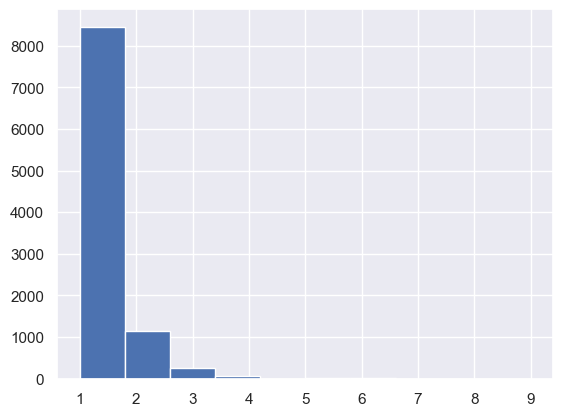

In [11]:
print(df_books[['author']].value_counts().describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
ax = df_books[['author']].value_counts().hist()
plt.show()

Most authors only (at least 75%) have one book reviewed on the site, and 95% of authors have 2 or fewer books reviewed, with the most being 9. I next look at the most reviewed authors.

              author  count
0  Joyce Carol Oates      9
1         Ian McEwan      9
2       Stephen King      9
3       John Grisham      8
4   Colson Whitehead      8
5      David Sedaris      8
6         Anne Perry      8
7                         7
8      Walter Mosley      7
9      Alice Hoffman      7


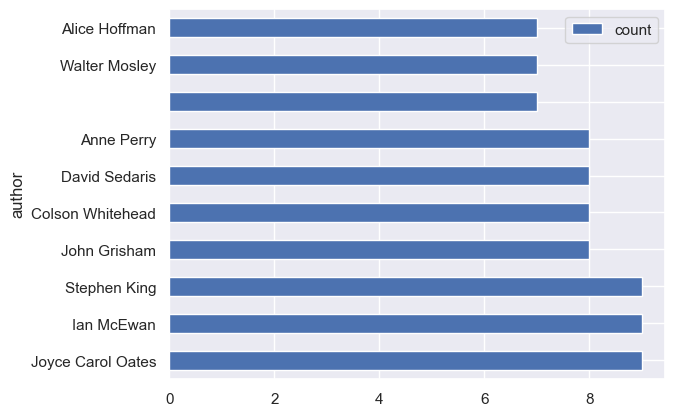

In [12]:
num_books_by_author = df_books[['author']].value_counts().reset_index()
print(num_books_by_author.head(10))
ax = num_books_by_author.set_index('author').head(10).plot(kind='barh')
plt.show()

The most reviewed authors are Ian McEwan, Joyce Carol Oates, and Stephen King. For some reason there are books without an author. I spot-checked a few on the webiste and found they did indeed have no author listed for some reason. I'm just going to code them as "Unknown" because I think they're still worth keeping. Later I might use some sort of book data API to recover the authors.

In [13]:
df_books.loc[df_books['author'] == '','author'] = 'Unknown'

Next I see the distribution of average rating by author. Since the vast majority of authors only have 1 book reviewed, this probably just looks like the distribution of ratings as a whole.

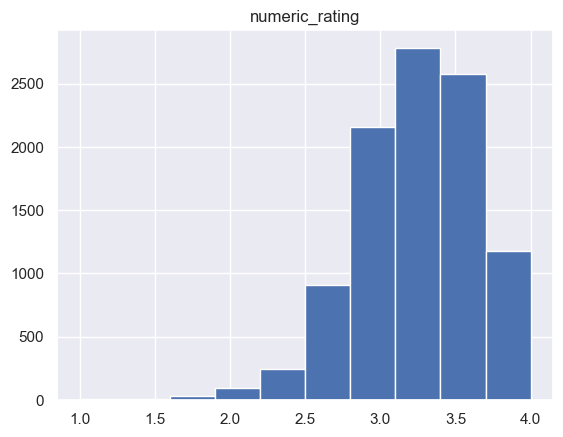

In [14]:
avg_review_by_author = df_reviews.merge(df_books, on='book_id').groupby('author')[['numeric_rating']].mean(numeric_only=True).sort_values('numeric_rating', ascending=False).reset_index()
ax = avg_review_by_author.hist()
plt.show()

I wonder if there's a relationship between number of books reviewed and average rating. Are better authors reviewed more?

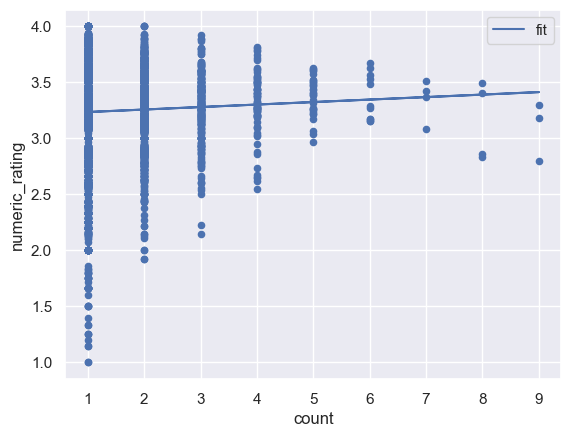

In [15]:
df_plot = avg_review_by_author.merge(num_books_by_author, on='author')
fig, ax = plt.subplots()
df_plot.plot(kind='scatter', x='count', y='numeric_rating', ax=ax)
m = sm.formula.ols('numeric_rating ~ count', data = df_plot)
res = m.fit()
df_plot.assign(fit=res.fittedvalues).plot(x='count', y='fit', ax=ax)
plt.show()

It seems like there's a slight positive relationship but nothing very extreme. The coefficient here is something like 0.02 which means even the top authors are only getting a boost in average rating by 0.2. There's just more variance the fewer books an author has written.

### Publisher

Now I take a similar look at publishers. There is one book for whom the publisher is an empty string so I set it to "Unknown".

In [16]:
print(df_books.loc[df_books['publisher'] == ''])
df_books.loc[df_books['publisher'] == '','publisher'] = 'Unknown'
df_publishers = df_books[['publisher']].drop_duplicates().reset_index(drop=True)
df_publishers.loc[:,'publisher_id'] = df_publishers.index
df_books = df_books.merge(df_publishers, on='publisher')

       book_id                    title  \
11161    11161  The Girl with the Leica   

                                         author publisher     publish_date  \
11161  Helena Janeczek, trans. by Ann Goldstein            October 8, 2019   

                                             description  \
11161  Gerda Taro was a German-Jewish war photographe...   

                                                 genres  \
11161  [Fiction, Historical, Literature in Translation]   

                                                    link  author_id  
11161  https://bookmarks.reviews/reviews/the-girl-wit...       9417  


count    846.000000
mean      14.319149
std       39.207321
min        1.000000
5%         1.000000
25%        1.000000
50%        2.000000
75%        8.000000
95%       78.750000
max      439.000000
Name: count, dtype: float64


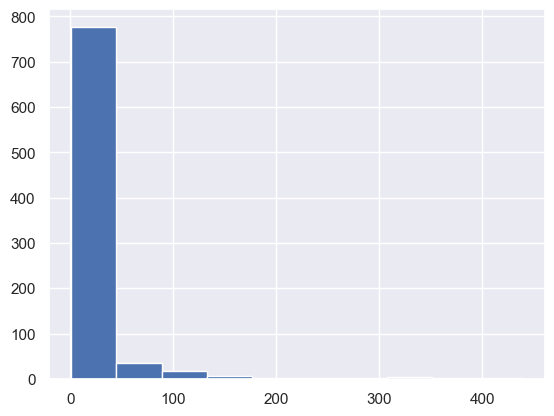

In [17]:
print(df_books[['publisher']].value_counts().describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
ax = df_books[['publisher']].value_counts().hist()
plt.show()

Most publishers have 2 or fewer books reviewed, but there are a few prolific publishers. I look at the most reviewed publishers.

                   publisher  count
0  Farrar, Straus and Giroux    439
1                      Knopf    382
2           Simon & Schuster    345
3     W. W. Norton & Company    331
4                     Harper    309
5               Random House    274
6                     Viking    235
7         St. Martin's Press    234
8              Penguin Press    214
9                   Scribner    153


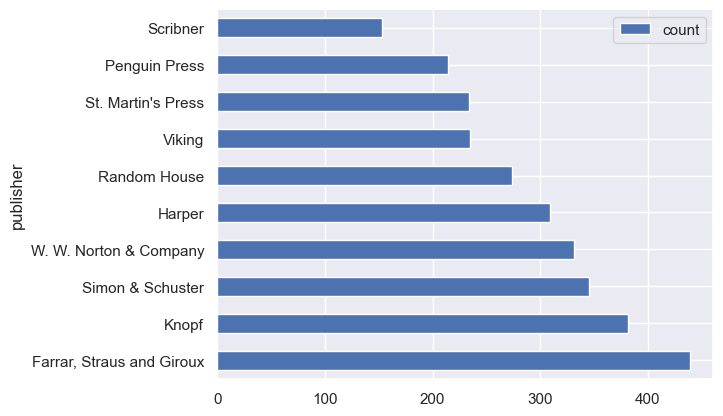

In [18]:
num_books_by_publisher = df_books[['publisher']].value_counts().reset_index()
print(num_books_by_publisher.head(10))
ax = num_books_by_publisher.set_index('publisher').head(10).plot(kind='barh')
plt.show()

Because of the skew, I want to check out the cumulative distribution when sorting by the number of books published. 

In [19]:
total_books = df_books.shape[0]
num_books_by_publisher.loc[:,'p'] = num_books_by_publisher['count'] / total_books
num_books_by_publisher.loc[:,'cumulative_p'] = num_books_by_publisher['p'].cumsum()
print(num_books_by_publisher.head(10))
print(f'50% of books are published by {num_books_by_publisher.loc[num_books_by_publisher['cumulative_p'] <= .5].shape[0]} publishers')

                   publisher  count         p  cumulative_p
0  Farrar, Straus and Giroux    439  0.036239      0.036239
1                      Knopf    382  0.031534      0.067773
2           Simon & Schuster    345  0.028479      0.096252
3     W. W. Norton & Company    331  0.027324      0.123576
4                     Harper    309  0.025508      0.149084
5               Random House    274  0.022618      0.171702
6                     Viking    235  0.019399      0.191101
7         St. Martin's Press    234  0.019316      0.210418
8              Penguin Press    214  0.017666      0.228083
9                   Scribner    153  0.012630      0.240713
50% of books are published by 38 publishers


The top 10 publishers are responsible for nearly 25% of books in the data, and 50% of books are published by 38 publishers. There are 846 publishers meaning 50% of books come from less than 5% of publishers.

In [20]:
num_books_by_publisher.loc[num_books_by_publisher['publisher'] == '']

,publisher,count,p,cumulative_p


Next I see the distribution of average rating by author. Since the vast majority of authors only have 1 book reviewed, this probably just looks like the distribution of ratings as a whole.

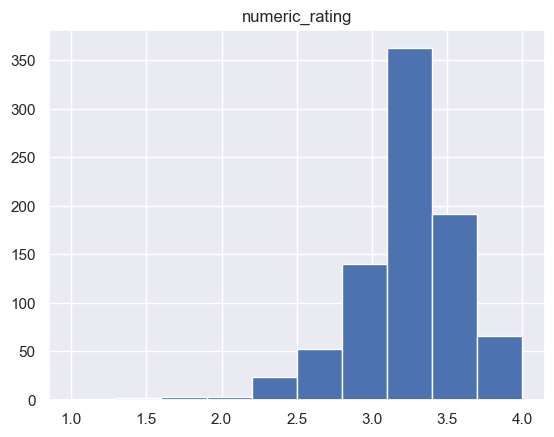

In [21]:
avg_review_by_publisher = df_reviews.merge(df_books, on='book_id').groupby('publisher')[['numeric_rating']].mean(numeric_only=True).sort_values('numeric_rating', ascending=False).reset_index()
ax = avg_review_by_publisher.hist()
plt.show()

I check if there's a relationship between number of books and average rating.

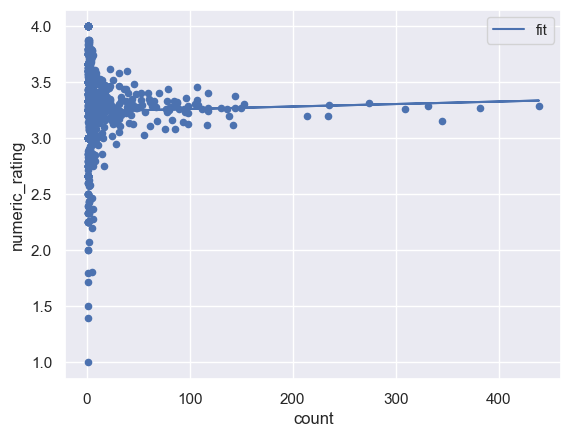

In [22]:
df_plot = avg_review_by_publisher.merge(num_books_by_publisher, on='publisher')
fig, ax = plt.subplots()
df_plot.plot(kind='scatter', x='count', y='numeric_rating', ax=ax)
m = sm.formula.ols('numeric_rating ~ count', data = df_plot)
res = m.fit()
df_plot.assign(fit=res.fittedvalues).plot(x='count', y='fit', ax=ax)
plt.show()

Maybe there's a relationship, but that looks pretty flat to me. Last thing that interests me is if any authors work with multiple publishers. 

In [23]:
publishers_by_author = df_books[['author', 'publisher']].drop_duplicates().groupby('author').count().reset_index().sort_values('publisher', ascending=False)
print(publishers_by_author.loc[publishers_by_author['publisher'] > 1])

                 author  publisher
9573            Unknown          7
5012  Joyce Carol Oates          6
2744   Edwidge Danticat          5
341       Alice Hoffman          5
7573        Patti Smith          5
...                 ...        ...
9595       Val McDermid          2
3800         Hilton Als          2
7138     Naomi Alderman          2
9590        Vaclav Smil          2
1853    Claire Lombardo          2

[901 rows x 2 columns]


No surprise that unknown authors work with different publishers, but I'm surprised some of the most reviewed authors also work with different publishers. I would've expected they would be signed with a specific publisher.

### Genres

Since the genres are a list, there will need to be some data wrangling to get them into a usable format. First, I create a genres DataFrame by exploding the `genres` column to create a `genre` column to create a row for each genre for each book. Then I count the number of genres and check out the top 10 most common and bottom 10 least common genres. The dataset holds 44 different genres. The top 2 are "Fiction" and "Non-Fiction", so later on I'm going to explore how often those occur with other genres to consider if they can be dropped or not; one of these seems to be used for every single book. Other top 10 genres seem to be more typical genre categories. On the bottom end, we have "Spooktacular Reads" and "2018 Film & TV Adaptations". I'll have to consider if some of these genres can be dropped or folded into others. Maybe "True Crime" belongs in "Mystery, Crime, &* Thriller"? I also know from using the site over the years that the Sci-Fi and Fantasy belong in the "Speculative" category.

In [24]:
df_genres = df_books[['book_id', 'genres']].explode('genres').rename(columns={'genres': 'genre'})
print("Number of unique genres:")
print(df_genres.nunique())
print("Top 10 most common genres:")
print(df_genres['genre'].value_counts().head(10) / df_books.shape[0])
print("Bottom 10 least common genres:")
print(df_genres['genre'].value_counts().tail(10) / df_books.shape[0])
# df_genres = pd.get_dummies(df_genres, columns=['genre'], dtype=int).groupby('book_id').max().reset_index()
# df_genres.describe()

Number of unique genres:
book_id    12114
genre         44
dtype: int64
Top 10 most common genres:
genre
Fiction                       0.493231
Non-Fiction                   0.491828
Literary                      0.215783
History                       0.145782
Memoir                        0.130840
Mystery, Crime, & Thriller    0.123906
Biography                     0.081063
Culture                       0.077266
Politics                      0.074047
Historical                    0.070910
Name: count, dtype: float64
Bottom 10 least common genres:
genre
True Crime                     0.006109
Graphic Nonfiction             0.003962
Sci-Fi and Fantasy             0.001899
Lit in Translation             0.001734
Best Books                     0.001321
Lithub                         0.001073
National Book Award Winners    0.000743
Health                         0.000660
Spooktacular Reads             0.000495
2018 Film & TV Adaptations     0.000165
Name: count, dtype: float64


First thing I want to look at is how often Fiction or Non-Fiction books have other labels available. What I'm going to do is just filter those out from the DataFrame and count the remaining number of books. 

In [25]:
all_books = all_books = df_genres['book_id'].unique().shape[0]
has_other_genres = df_genres.loc[~(df_genres['genre'].isin(['Fiction', 'Non-Fiction'])),'book_id'].unique().shape[0]
has_other_genres / all_books

0.9597160310384679

Just about 96% of books have at least 1 other genre than Fiction or Non-Fiction. I don't like to throw away data, but I'm wary of these two genres dominating the others when we finally get into modeling the data. For now, I'm going to drop them, but might come back later with an approach to impute other genres for the books being dropped (perhaps using NLP). 

In [26]:
df_genres = df_genres.loc[~(df_genres['genre'].eq('Fiction') | df_genres['genre'].eq('Non-Fiction'))]

I also check the "Hottest Books of the Season", "Best Books", "Award Winners", and "National Book Award Winners" categories because it's unclear how these labels are assigned; I worry they might be assigned based on review ratings instead of giving information not known at the time of rating.

In [27]:
all_books = df_genres['book_id'].unique().shape[0]
has_other_genres = df_genres.loc[~(df_genres['genre'].isin(['Hottest Books of the Season', 'Best Books', 'Award Winners', 'National Book Award Winners'])),'book_id'].unique().shape[0]
has_other_genres / all_books

0.9982797178737313

99.82% of books have another label besides "Hottest Books of the Season", "Best Books", "Award Winners", or "National Book Award Winners" so I'm also going to drop those.

In [28]:
df_genres = df_genres.loc[~(df_genres['genre'].isin(['Hottest Books of the Season', 'Best Books', 'Award Winners', 'National Book Award Winners']))]

With those dropped, I check out a bar chart of book counts by the remaining genres.

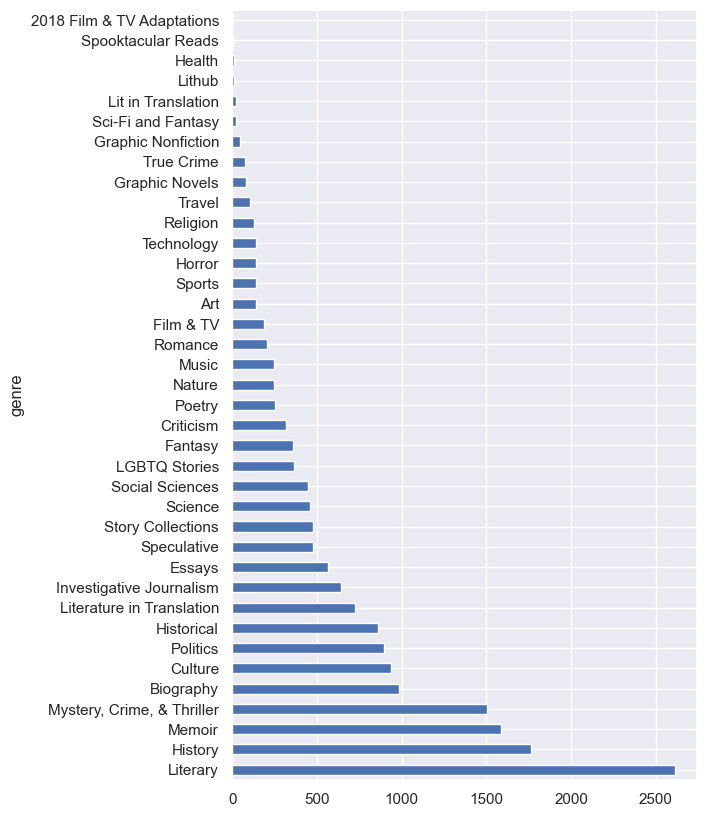

In [29]:
plt.figure(figsize=(6,10))
ax = df_genres['genre'].value_counts().plot(kind='barh')

Based on this plot, I'm going to combine categories in a few ways. I'll recode "Lit in Translation" to "Literature in Translation", "Spooktacular Reads" to "Horror", "2018 Film & TV Adaptations" to "Film & TV", and "True Crime" to "Mystery, Crime, & Thriller".

In [30]:
df_genres.loc[:,'genre'] = df_genres['genre'].replace({
    'Lit in Translation': 'Literature in Translation',
    'Spooktacular Reads': 'Horror',
    '2018 Film & TV Adaptations': 'Film & TV',
    'True Crime': 'Mystery, Crime, & Thriller'
})

In [31]:
df_genres.nunique()

book_id    11606
genre         34
dtype: int64

One way to look at collapsing genres is to look for strong correlations between certain genres. I create a correlation matrix, but because it's quite large, I look at a heatmap instead of looking at the table itself. 

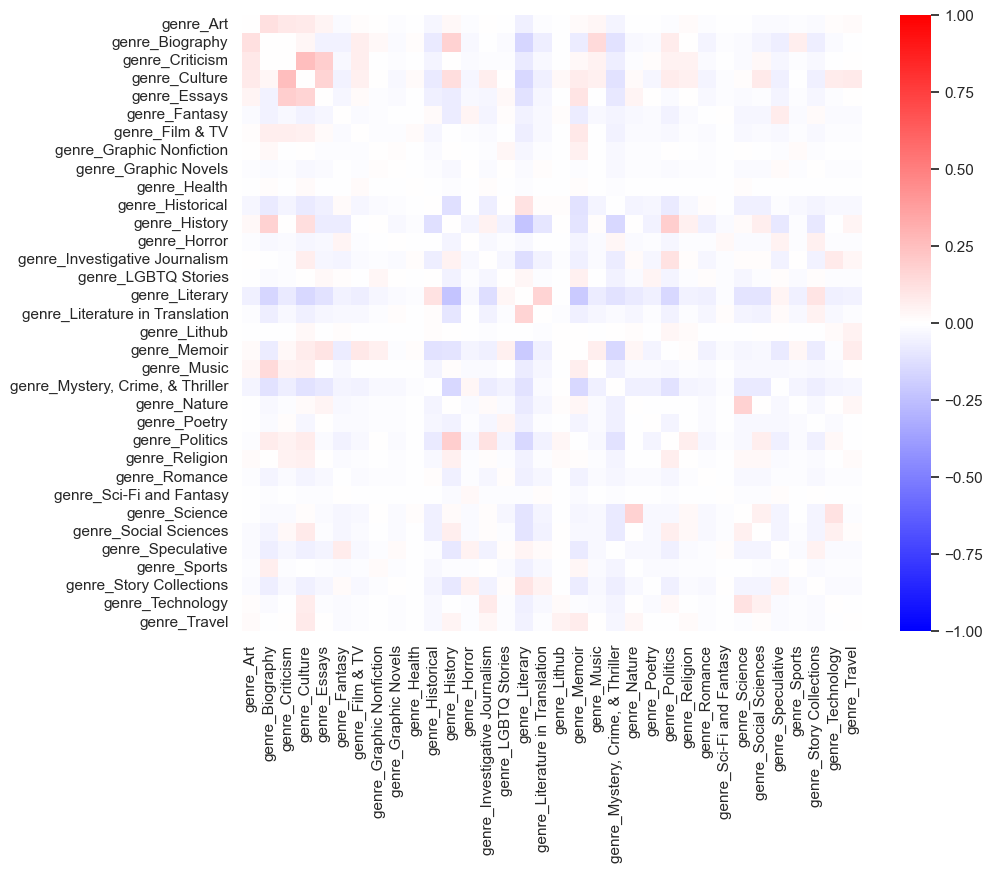

In [32]:
corr_matrix = pd.get_dummies(df_genres, columns=['genre'], dtype=int).groupby('book_id').max().reset_index().drop(columns='book_id').corr()
for i in range(corr_matrix.shape[0]):
    corr_matrix.iloc[i,i] = 0
plt.figure(figsize=(10,8)) 
ax = sns.heatmap(corr_matrix, cmap='bwr', center=0, vmin=-1, vmax=1)
plt.show()

Nothing really stands out to me as a candidate for recoding, so I'm happy with how the genre feature looks now.

### Reviews

In [29]:
df_reviews = df_reviews.merge(df_books['book_id'], on='book_id', how='inner')
print(f'Total number of reviews {df_reviews.shape[0]}')
print(df_reviews.nunique())

Total number of reviews 83072
book_id             12117
review_author       15552
review_publisher     1856
review_rating           4
review_text         82994
review_link         81364
numeric_rating          4
dtype: int64


#### Review Authors

In [ ]:
df_reviews.loc[:,'review_author'] = df_reviews['review_author'].map(lambda x: re.sub(r',$', '', x))
df_reviews.loc[df_reviews['review_author'] == "", 'review_author'] = df_reviews.loc[df_reviews['review_author'] == "", 'review_publisher']

#### Review publisher

I happened to notice while looking through the data that the review publisher name is not consistent. A publisher like The New York Times could be under its name as written with or without the "The" or with "Book Review" or "Review of Books" added. I even noticed some instances where the publisher did not match the actually link of the review. To remedy this, I'm going to parse the review url and to get the domain name of the review, then I'll use that as the ground truth. To add a better label, I'll just look for the most used value in the `review_publisher` column.

In [31]:
print('Number of times different names for The New York Times are used:')
print(df_reviews.loc[df_reviews['review_publisher'].str.contains('New York Times'),'review_publisher'].value_counts())

Number of times different names for The New York Times are used:
review_publisher
The New York Times Book Review           3878
The New York Times                        967
New York Times Book Review                271
New York Times                             65
The New York Times Sunday Book Review      54
The New York Times Review of Books          3
The New York Times Book                     2
The New York Times Books Review             2
New York Times Review of Books              1
The New York Times Style Magazine           1
The New York Times  Book Review             1
Name: count, dtype: int64


In [36]:
print(f'Dropping {df_reviews.loc[~df_reviews['review_link'].str.contains('http')].shape[0]} reviews without "http" in the link url.')
df_reviews = df_reviews.loc[df_reviews['review_link'].str.contains('http')]
df_reviews.loc[:,'review_domain'] = df_reviews['review_link'].apply(lambda url : extract(url).domain)
df_reviews['review_domain'].value_counts()
domain_publisher_map = df_reviews.groupby(['review_domain', 'review_publisher']).size().reset_index(drop=False, name='count').sort_values(by='count', ascending=False).groupby('review_domain').head(1)
df_reviews = pd.merge(
    df_reviews.drop(columns='review_publisher'),
    domain_publisher_map.drop(columns='count'),
    on='review_domain',
    how='inner'
)

Dropping 453 reviews without "http" in the link url.


The distribution of reviewed books among publishers is highly skewed. 

In [57]:
num_reviews_by_publisher = df_reviews['review_publisher'].value_counts().reset_index()
print(num_reviews_by_publisher.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))
num_reviews_by_publisher.loc[:,'cumulative_p'] = num_reviews_by_publisher['count'].cumsum() / df_reviews.shape[0]
num_reviews_by_publisher.head(10)

             count
count   962.000000
mean     86.353430
std     576.678348
min       1.000000
25%       1.000000
50%       2.000000
75%      10.000000
90%      72.000000
95%     229.600000
99%    1657.030000
max    9704.000000


,review_publisher,count,cumulative_p
0,Publishers Weekly,9704,0.116814
1,Kirkus,9417,0.230174
2,Booklist,6747,0.311393
3,The New York Times Book Review,5320,0.375433
4,Library Journal,3574,0.418456
5,The Washington Post,3146,0.456327
6,The Guardian (UK),3021,0.492693
7,The Wall Street Journal,3001,0.528818
8,BookPage,2354,0.557155
9,New York Journal of Books,1704,0.577668


In [47]:
df_reviews['review_publisher'].value_counts().cumsum().reset_index()

count     962.000000
mean       86.353430
std       576.678348
min         1.000000
25%         1.000000
50%         2.000000
75%        10.000000
max      9704.000000
Name: count, dtype: float64

#### Ratings

Here I look at the distribution of review ratings.

review_rating
Rave        0.434491
Positive    0.434286
Mixed       0.106402
Pan         0.024822
Name: proportion, dtype: float64


<Axes: >

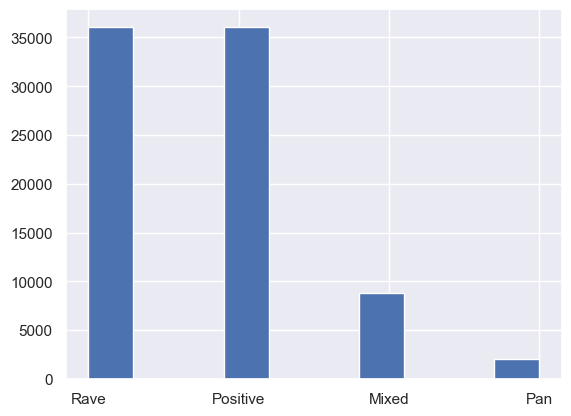

In [ ]:
print(df_reviews['review_rating'].value_counts(normalize=True))
df_reviews['review_rating'].hist()

Around 86% of reviews are either "Rave" or "Positive". There may be selection bias affecting reviews; critics only review promising or popular books.

Next we convert ratings to a 4-point scales and check the new summary statistics.

In [143]:
print(df_reviews['numeric_rating'].describe())

count    83072.000000
mean         3.278445
std          0.750103
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          4.000000
Name: numeric_rating, dtype: float64


No surprises given the distribution we saw previously. The average review is positive. Now we'll check out how ratings differ when separated by other variables, such as book genre or publisher.

In [34]:
df_reviews_genres = df_reviews.merge(df_genres, on='book_id')
df_reviews_genres.drop(columns='book_id').groupby('genre').describe()

numeric_rating                                     \
                                    count      mean       std  min  25%  50%   
genre                                                                          
Art                                 961.0  3.265349  0.752313  1.0  3.0  3.0   
Biography                          7360.0  3.207065  0.753164  1.0  3.0  3.0   
Criticism                          2168.0  3.190037  0.803116  1.0  3.0  3.0   
Culture                            6076.0  3.204411  0.766599  1.0  3.0  3.0   
Essays                             3925.0  3.334522  0.721692  1.0  3.0  3.0   
Fantasy                            2273.0  3.376595  0.738657  1.0  3.0  4.0   
Film & TV                          1331.0  3.205860  0.767573  1.0  3.0  3.0   
Graphic Nonfiction                  337.0  3.480712  0.650377  1.0  3.0  4.0   
Graphic Novels                      465.0  3.486022  0.626566  1.0  3.0  4.0   
Health                               48.0  3.312500  0.803086  1.0  3.0  3.5   
Historical                         6532.0  3.318279  0.770901  1.0  3.0  3.0   
History                           11187.0  3.259140  0.712319  1.0  3.0  3.0   
Horror                             1082.0  3.324399  0.773722  1.0  3.0  3.0   
Investigative Journalism           4013.0  3.236481  0.716662  1.0  3.0  3.0   
LGBTQ Stories                      2862.0  3.409853  0.736107  1.0  3.0  4.0   
Literary                          23883.0  3.321986  0.781022  1.0  3.0  3.0   
Literature in Translation          5270.0  3.281973  0.749642  1.0  3.0  3.0   
Lithub                               56.0  2.892857  0.705268  1.0  3.0  3.0   
Memoir                            10644.0  3.317268  0.716222  1.0  3.0  3.0   
Music                              1583.0  3.228680  0.731803  1.0  3.0  3.0   
Mystery, Crime, & Thriller         9389.0  3.262222  0.764604  1.0  3.0  3.0   
Nature                             1638.0  3.394383  0.671084  1.0  3.0  3.0   
Poetry                             1536.0  3.579427  0.610607  1.0  3.0  4.0   
Politics                           5388.0  3.075538  0.807687  1.0  3.0  3.0   
Religion                            745.0  3.088591  0.811670  1.0  3.0  3.0   
Romance                            1004.0  3.296813  0.692899  1.0  3.0  3.0   
Sci-Fi and Fantasy                  182.0  3.208791  0.800780  1.0  3.0  3.0   
Science                            2662.0  3.232908  0.706335  1.0  3.0  3.0   
Social Sciences                    2695.0  3.141744  0.761415  1.0  3.0  3.0   
Speculative                        3801.0  3.283873  0.789520  1.0  3.0  3.0   
Sports                              754.0  3.287798  0.684245  1.0  3.0  3.0   
Story Collections                  3567.0  3.473227  0.670505  1.0  3.0  4.0   
Technology                          819.0  3.001221  0.785721  1.0  3.0  3.0   
Travel                              672.0  3.218750  0.710622  1.0  3.0  3.0   

                                      
                            75%  max  
genre                                 
Art                         4.0  4.0  
Biography                   4.0  4.0  
Criticism                   4.0  4.0  
Culture                     4.0  4.0  
Essays                      4.0  4.0  
Fantasy                     4.0  4.0  
Film & TV                   4.0  4.0  
Graphic Nonfiction          4.0  4.0  
Graphic Novels              4.0  4.0  
Health                      4.0  4.0  
Historical                  4.0  4.0  
History                     4.0  4.0  
Horror                      4.0  4.0  
Investigative Journalism    4.0  4.0  
LGBTQ Stories               4.0  4.0  
Literary                    4.0  4.0  
Literature in Translation   4.0  4.0  
Lithub                      3.0  4.0  
Memoir                      4.0  4.0  
Music                       4.0  4.0  
Mystery, Crime, & Thriller  4.0  4.0  
Nature                      4.0  4.0  
Poetry                      4.0  4.0  
Politics                    4.0  4.0  
Religion     

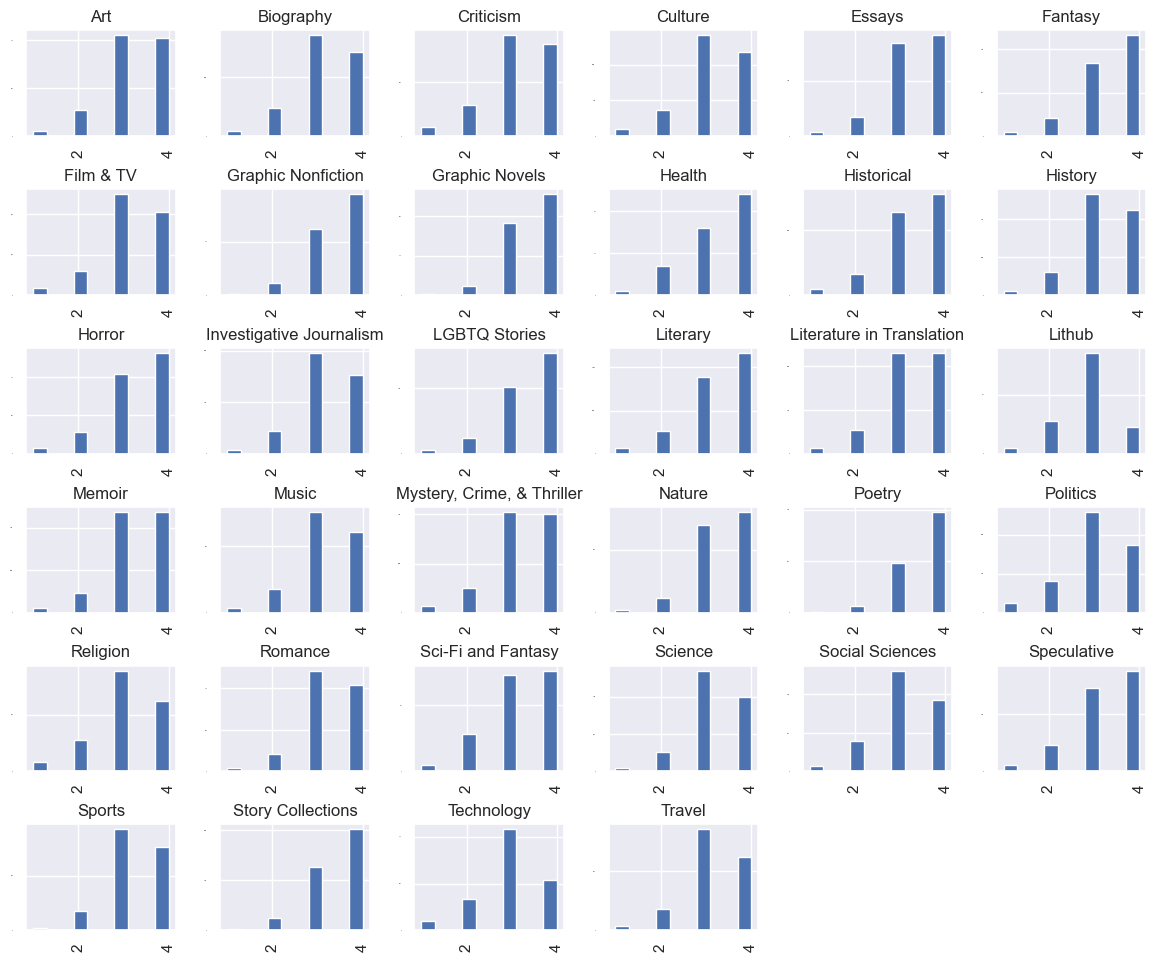

In [163]:
axes = df_reviews_genres.hist(column='numeric_rating', by='genre', figsize=(14, 12), ylabelsize=0)
plt.show()

Aside from the small Lithub category, it seems like technology books receive the lowest reviews, albeit still average a positive review, while poetry books generally receive rave reviews. To get a better sense of it, I find the average review for each book and look at similar plots, this time showing boxplots.

In [148]:
genre_review_means = df_reviews.merge(df_genres, on='book_id').groupby(by=['genre', 'book_id'])[['numeric_rating']].mean()
genre_review_means.groupby('genre').describe()

numeric_rating                                \
                                    count      mean       std       min   
genre                                                                     
Art                                 143.0  3.242077  0.445793  1.333333   
Biography                           983.0  3.177138  0.406798  1.250000   
Criticism                           316.0  3.149694  0.469442  1.400000   
Culture                             937.0  3.198523  0.427357  1.000000   
Essays                              565.0  3.326262  0.389546  1.684211   
Fantasy                             358.0  3.350416  0.410438  1.666667   
Film & TV                           192.0  3.199591  0.421502  1.666667   
Graphic Nonfiction                   48.0  3.430634  0.458958  1.666667   
Graphic Novels                       81.0  3.418979  0.349414  2.500000   
Health                                8.0  3.188690  0.599407  2.250000   
Historical                          859.0  3.278319  0.389591  1.833333   
History                            1768.0  3.235326  0.389499  1.666667   
Horror                              141.0  3.322353  0.441444  2.000000   
Investigative Journalism            639.0  3.204519  0.413194  1.500000   
LGBTQ Stories                       363.0  3.366890  0.376381  2.066667   
Literary                           2614.0  3.297519  0.394704  1.636364   
Literature in Translation           746.0  3.268996  0.412725  1.500000   
Lithub                               13.0  2.916667  0.326315  2.500000   
Memoir                             1585.0  3.291243  0.418989  1.000000   
Music                               244.0  3.215139  0.400207  2.000000   
Mystery, Crime, & Thriller         1575.0  3.218708  0.414194  1.666667   
Nature                              249.0  3.363980  0.360104  2.250000   
Poetry                              255.0  3.570432  0.340172  2.500000   
Politics                            898.0  3.046180  0.521070  1.000000   
Religion                            128.0  3.047397  0.478552  1.400000   
Romance                             207.0  3.251917  0.415630  1.833333   
Sci-Fi and Fantasy                   23.0  3.212465  0.457630  2.000000   
Science                             459.0  3.191925  0.429334  1.333333   
Social Sciences                     449.0  3.107833  0.441443  1.666667   
Speculative                         476.0  3.267556  0.407696  2.142857   
Sports                              140.0  3.265786  0.417269  1.800000   
Story Collections                   474.0  3.460582  0.358373  2.000000   
Technology                          138.0  2.981646  0.459085  1.333333   
Travel                              106.0  3.183305  0.378364  2.000000   

                                                                    
                                 25%       50%       75%       max  
genre                                                               
Art                         3.000000  3.250000  3.620192  4.000000  
Biography                   3.000000  3.222222  3.466667  4.000000  
Criticism                   2.825000  3.200000  3.451389  4.000000  
Culture                     3.000000  3.230769  3.500000  4.000000  
Essays                      3.000000  3.333333  3.642857  4.000000  
Fantasy                     3.000000  3.400000  3.666667  4.000000  
Film & TV                   3.000000  3.250000  3.500000  4.000000  
Graphic Nonfiction          3.237500  3.516667  3.684211  4.000000  
Graphic Novels              3.250000  3.454545  3.666667  4.000000  
Health                      2.850000  3.371429  3.675000  3.750000  
Historical                  3.000000  3.333333  3.571429  4.000000  
History                     3.000000  3.250000  3.500000  4.000000  
Horror                      3.000000  3.384615  3.600000  4.000000  
Investigative Journalism    3.000000  3.250000  3.500000  4.000000  
LGBTQ Stories               3.166667  3.416667  3.666667  4.000000  
Literary 

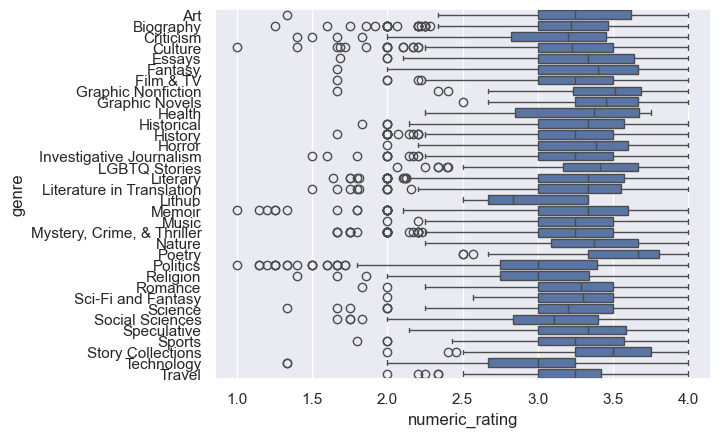

In [165]:
axes = sns.boxplot(genre_review_means, x='numeric_rating', y='genre')
plt.show()

Index(['numeric_rating'], dtype='object')

#### Number of reviews

##### By book

Here we look at the distribution of number of reviews for each book. The mean number of reviews is nearly 7, with 95% of books having 15 reviews or fewer.

count    12117.000000
mean         6.855822
std          4.941797
min          1.000000
5%           3.000000
25%          4.000000
50%          6.000000
75%          8.000000
95%         15.000000
max         80.000000
dtype: float64


<Axes: >

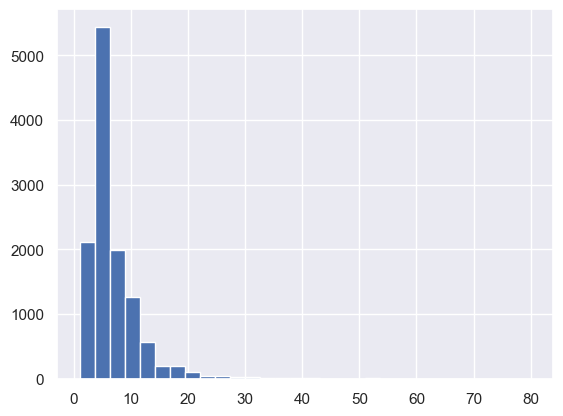

In [145]:
review_counts = df_reviews.groupby(by='book_id').size()
print(review_counts.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
review_counts.hist(bins=30)

##### By author

##### By genre



In [ ]:
genre_review_counts = df_reviews.merge(df_genres, on='book_id').groupby(by=['genre', 'book_id']).size()
genre_review_counts.groupby('genre').describe()

,count,mean,std,min,25%,50%,75%,max
genre,,,,,,,,
Art,143.0,6.720280,3.995430,3.0,4.00,5.0,9.00,22.0
Biography,983.0,7.492370,4.378909,2.0,4.00,6.0,9.00,37.0
Criticism,316.0,6.860759,4.908649,2.0,4.00,5.0,8.00,36.0
Culture,937.0,6.488794,3.874656,2.0,4.00,6.0,8.00,36.0
Essays,565.0,6.946903,5.107082,2.0,4.00,5.0,8.00,36.0
Fantasy,358.0,6.349162,4.685443,2.0,4.00,5.0,7.00,43.0
Film & TV,192.0,6.932292,3.705182,3.0,4.00,6.0,9.00,30.0
Graphic Nonfiction,48.0,7.020833,4.817917,3.0,4.00,5.0,8.25,22.0
Graphic Novels,81.0,5.740741,2.910231,3.0,3.00,5.0,8.00,13.0


In [147]:
genre_review_counts

genre   book_id
Art     71          6
        254         5
        407         4
        452         7
        599        14
                   ..
Travel  11723      12
        11747       4
        11761       5
        11802      13
        11858      10
Length: 18180, dtype: int64

In [14]:
df_reviewers = df_reviews[['review_author']].drop_duplicates().reset_index(drop=True)
df_reviewers.loc[:,'review_author_id'] = df_reviewers.index
df_reviewers.shape[0]

15552

review_author
Unknown                20106
Sam Sacks                513
Donna Seaman             445
Ron Charles              318
Steve Donoghue           279
                       ...  
Jane Jakeman               1
Jane Jorgensen             1
Jane Keenan                1
Jane O\\\\\\\'Grady        1
﻿Walter Clemens            1
Name: count, Length: 15552, dtype: int64
count    15552.000000
mean         5.341564
std        161.698748
min          1.000000
5%           1.000000
25%          1.000000
50%          1.000000
75%          3.000000
95%         13.000000
max      20106.000000
Name: count, dtype: float64


<Axes: >

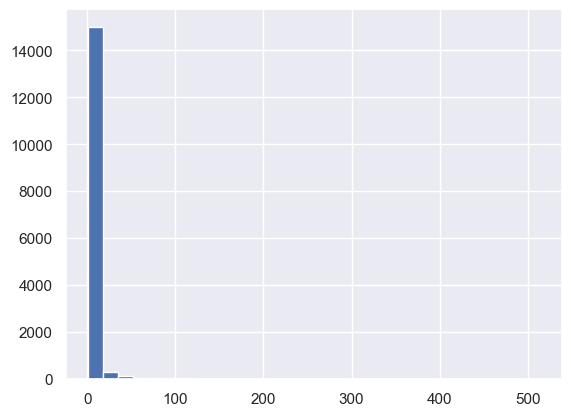

In [15]:
print(df_reviews.value_counts('review_author'))
print(df_reviews.value_counts('review_author').describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
ax = df_reviews.loc[df_reviews['review_author'] != 'Unknown'].value_counts('review_author').hist(bins=30)
plt.show()

review_publisher
Publishers Weekly                 9410
Kirkus                            9321
Booklist                          6746
The New York Times Book Review    3878
Library Journal                   3545
                                  ... 
The Aspen Daily News                 1
The Aspen Times                      1
Friday Magazine                      1
Friday (UAE)                         1
SLJ                                  1
Name: count, Length: 1856, dtype: int64
count    1856.000000
mean       44.758621
std       393.179669
min         1.000000
5%          1.000000
25%         1.000000
50%         1.000000
75%         5.000000
95%       105.000000
max      9410.000000
Name: count, dtype: float64


<Axes: >

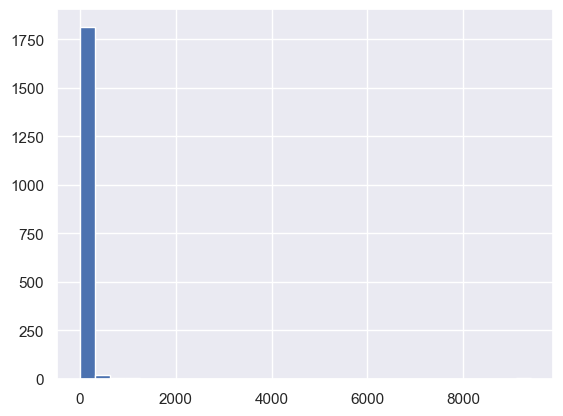

In [17]:
print(df_reviews.value_counts('review_publisher'))
print(df_reviews.value_counts('review_publisher').describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))
df_reviews.loc[df_reviews['review_publisher'] != 'Unknown'].value_counts('review_publisher').hist(bins=30)

count    1085.000000
mean       76.564055
std       536.770893
min         1.000000
25%         1.000000
50%         2.000000
75%         8.000000
max      9699.000000
Name: count, dtype: float64

In [ ]:

df_reviews.groupby(['review_domain', 'review_publisher']).count()

book_id  review_author  review_rating  \
review_domain review_publisher                                          
                                    352            352            352   
 Cogdill ews  AP News                 1              1              1   
 Greenwald    The Baffler             1              1              1   
 Miller       Library Journal         1              1              1   
 Rubin        The Guardian            1              1              1   
...                                 ...            ...            ...   
zibbymag      Zibby Mag               1              1              1   
zyzzyva       ZYZYVA                  1              1              1   
              ZYZZYVA               121            121            121   
              ZZYZZYVA                1              1              1   
              Zyzzyva                 6              6              6   

                                review_text  review_link  numeric_rating  
review_domain review_publisher                                            
                                        352          352             352  
 Cogdill ews  AP News                     1            1               1  
 Greenwald    The Baffler                 1            1               1  
 Miller       Library Journal             1            1               1  
 Rubin        The Guardian                1            1               1  
...                                     ...          ...             ...  
zibbymag      Zibby Mag                   1            1               1  
zyzzyva       ZYZYVA                      1            1               1  
              ZYZZYVA                   121          121             121  
              ZZYZZYVA                    1            1               1  
              Zyzzyva                     6            6               6  

[2212 rows x 6 columns]

In [112]:
df_reviews.loc[df_reviews['review_domain'] == '']

,book_id,review_author,review_publisher,review_rating,review_text,review_link,numeric_rating,review_domain
74,9,Arlene McKanic,,Rave,"Sprawling, passionate, tragic and comedic at t...",,4,
585,100,Unknown,,Positive,Through his work as an expert in the science o...,,3,
768,132,Yasmine El Rashidi,,Rave,There could be no better guide to the upheaval...,,4,
1022,174,Laurie Hertzel,,Rave,Mitenbuler's prose strikes just the right tone...,,4,
1121,196,Álvaro Enrigue,,Rave,The femicide of Liliana Rivera Garza went almo...,,4,
...,...,...,...,...,...,...,...,...
82060,12008,Unknown,,Positive,Campbell sheds further light on the (decidedly...,,3,
82138,12013,Unknown,,Positive,In her follow-up to the National Book Award-wi...,,3,
82422,12040,Unknown,,Positive,Percy turns in a fast-paced thriller with cris...,,3,
82708,12071,Unknown,,Rave,"Yoon proves himself a literary alchemist, tran...",,4,
